In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## Polynomial Trajectory Generation

### The Core Concept

A polynomial trajectory is represented as:
$$p(t) = c_0 + c_1 t + c_2 t^2 + ... + c_{P-1} t^{P-1}$$

where $c_i$ are the polynomial coefficients we need to find.

### Constraint Factor Function

The `constraint_factor` function builds rows of a constraint matrix. For a derivative of degree `deg` at time `dt`:
- It computes the falling factorial: $\frac{i!}{(i-deg)!}$ for indices $i = deg, ..., O-1$
- This represents the derivative of the polynomial basis functions at time `dt`

### Solving for Coefficients

Given boundary conditions (position, velocity, acceleration, jerk) at start (t=0) and end (t=1), we:
1. Build a constraint matrix $A$ where each row represents one constraint
2. Stack boundary conditions into vector $b$
3. Solve the linear system $Ax = b$ to find coefficients $c$

This ensures our polynomial satisfies all the specified boundary conditions exactly.

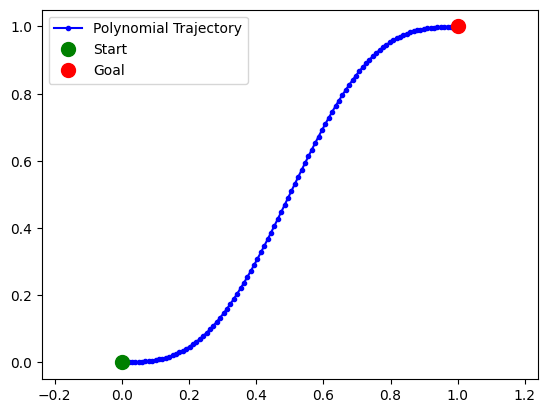

In [ ]:
def constraint_factor(row: torch.Tensor, deg: int, O: int, dt: float = 1.0):
    """
    Mutates `row` (shape [1, 2*O]) in place.
    Sets row[:, deg:O] = falling factorial i!/(i-deg)! for i=deg..O-1
    and row[:, O+deg] = -row[:, deg].
    """
    # clear existing contents IN-PLACE
    row.zero_()

    # i indices
    i = torch.arange(deg, O, device=row.device, dtype=row.dtype)
    # times
    t = (torch.ones_like(i) * dt).pow(i - deg)
    # falling factorial i!/(i-deg)! = exp(lgamma(i+1) - lgamma(i-deg+1))
    vals = torch.exp(torch.lgamma(i + 1) - torch.lgamma(i - deg + 1)) * t
    row[..., :, deg:O] = vals

# example construct polynomial from start and end constraints
P = 8 # polynomial order 7 + 1
S = P//2
A = torch.zeros((P, P)) # linear constraint matrix
for i in range(P//2):
    constraint_factor(A[i:i+1], i, P, dt=0.0) # ith derivative at time 0
    constraint_factor(A[i+S:i+S+1], i, P, dt=1.0) # ith derivative at time 1.0

start = torch.tensor(
    [[0.0, 0.0],    # pos
     [1.0, 0.0],    # vel
     [0.0, 1.0],    # acc
     [0.0, 0.0]],   # jerk
)
goal = torch.tensor(
    [[1.0, 1.0],    # pos
     [1.0, 0.0],    # vel
     [0.0, -1.0],    # acc
     [0.0, 0.0]],   # jerk
)
b = torch.cat((start, goal), dim=0)  # shape (2*S, D)
# solve for coefficients
c = torch.linalg.solve(A, b)  # shape (P, D)


# sampling matrix
A_s_pos = torch.zeros((100, P))
A_s_vel = torch.zeros((100, P))
for i in range(100):
    t = i / 99.0
    constraint_factor(A_s_pos[i:i+1], 0, P, dt=t) # pos at time t
    constraint_factor(A_s_vel[i:i+1], 1, P, dt=t) # vel at time t
pos = A_s_pos @ c  # shape (100, D)
vel = A_s_vel @ c  # shape (100, D)
plt.plot(pos[:,0], pos[:,1], 'b.-', label='Polynomial Trajectory')
plt.plot(start[0,0], start[0,1], 'go', markersize=10, label='Start')
plt.plot(goal[0,0], goal[0,1], 'ro', markersize=10, label='Goal')
plt.axis('equal')
plt.legend()
plt.show()

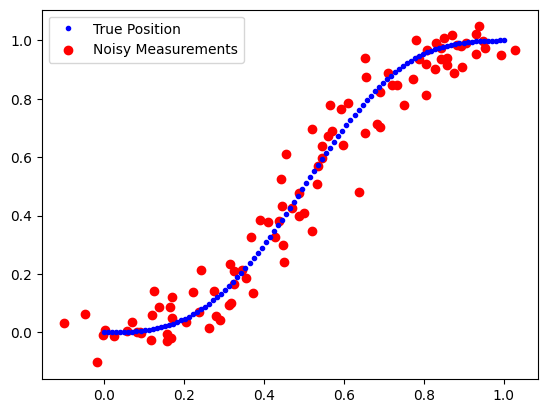

In [ ]:
# create example dataset
torch.manual_seed(4)
pos_data = pos + 0.05 * torch.randn_like(pos)

plt.plot(pos[:,0], pos[:,1], 'b.', label='True Position')
plt.scatter(pos_data[:,0], pos_data[:,1], c='r', label='Noisy Measurements')
plt.legend()

## Least Squares Fitting (Factor Graph Optimization)

Now we pretend we don't know the true trajectory and only have noisy measurements. Can we recover a smooth polynomial?

### The Optimization Problem

We want to minimize the squared error between our polynomial and the measurements:
$$\min_{c} \frac{1}{2} \|A_{ls} c - b_{ls}\|^2$$

where:
- $A_{ls}$ is the sampling matrix (evaluates polynomial at measurement times)
- $b_{ls}$ are the noisy position measurements
- $c$ are the polynomial coefficients to find

### Closed-Form Solution

The least squares solution is:
$$c_{ls} = (A_{ls}^T A_{ls})^{-1} A_{ls}^T b_{ls}$$

This is the same technique used in factor graph optimization and bundle adjustment! By fitting a smooth polynomial, we're effectively filtering out measurement noise.

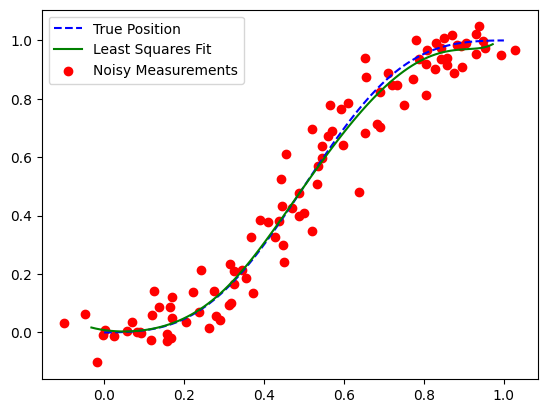

In [ ]:
# least squares fit ("factor-graph opt")
# min 1/2 (A x - b)^2  ->  min 1/2 x^T (A^T A) x - b^T A x + 1/2 b^T b
# x = (A^T A)^-1 (A^T b)
A_ls = A_s_pos  # shape (100, P)
b_ls = pos_data  # shape (100, D)
AtA = A_ls.T @ A_ls  # shape (P, P)
Atb = A_ls.T @ b_ls  # shape (P, D)

c_ls = torch.linalg.solve(AtA, Atb)  # shape (P, D)

plt.plot(pos[:,0], pos[:,1], 'b--', label='True Position')
plt.plot((A_ls @ c_ls)[:,0], (A_ls @ c_ls)[:,1], 'g-', label='Least Squares Fit')
plt.scatter(pos_data[:,0], pos_data[:,1], c='r', label='Noisy Measurements')
plt.legend()
plt.show()
